In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Importer le dataset Online Retail
df = pd.read_excel('data/processed/Online_Retail.xlsx')

ImportError: Missing optional dependency 'openpyxl'.  Use pip or conda to install openpyxl.

In [5]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


# **Preprocessing**

In [6]:
#Supprimer les CustomerID manquants
df = df.dropna(subset=['CustomerID'])

#Transformer le types de la variable CustomerID en int
df['CustomerID'] = df['CustomerID'].astype(int)

In [7]:
df.shape

(406829, 8)

In [8]:
#Supprimer les commandes commençant par 'C' sont des annulations/retours
before = len(df)
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

print(f"Commandes annulées supprimées : {before - len(df):,} lignes retirées")
print(f"   Dataset restant : {len(df):,} lignes")

Commandes annulées supprimées : 8,905 lignes retirées
   Dataset restant : 397,924 lignes


In [10]:
before = len(df)
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

print(f"Quantités négatives et prix à 0 supprimés : {before - len(df):,} lignes retirées")
print(f"   Dataset restant : {len(df):,} lignes")

Quantités négatives et prix à 0 supprimés : 0 lignes retirées
   Dataset restant : 397,884 lignes


In [12]:
before = len(df)
df = df.drop_duplicates()

print(f"Doublons supprimés : {before - len(df):,} lignes retirées")
print(f"   Dataset final propre : {len(df):,} lignes")

Doublons supprimés : 0 lignes retirées
   Dataset final propre : 392,692 lignes


# Feature Engineering RFM

Calcul du montant total par ligne

In [15]:
# Chaque ligne = une transaction → prix total = quantité × prix unitaire
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print(f"Variable TotalPrice créée")
print(f"   Montant moyen par transaction : £{df['TotalPrice'].mean():.2f}")
print(f"   Montant total du dataset      : £{df['TotalPrice'].sum():,.2f}")

✅ Variable TotalPrice créée
   Montant moyen par transaction : £22.63
   Montant total du dataset      : £8,887,208.89


In [16]:
df[['InvoiceNo', 'CustomerID', 'Quantity', 'UnitPrice', 'TotalPrice']].head(5)

,InvoiceNo,CustomerID,Quantity,UnitPrice,TotalPrice
0,536365,17850,6,2.55,15.30
1,536365,17850,6,3.39,20.34
2,536365,17850,8,2.75,22.00
3,536365,17850,6,3.39,20.34
4,536365,17850,6,3.39,20.34



RFM = Recency, Frequency, Monetary — c'est la méthode marketing la plus utilisée pour segmenter des clients. Voici ce que chaque lettre signifie :

  * R — Recency : Combien de jours depuis le dernier achat ? (plus c'est petit, mieux c'est)
  * F — Frequency : Combien de commandes distinctes a-t-il passées ?
  * M — Monetary : Combien a-t-il dépensé au total ?

Date de référence pour le calcul RFM

In [13]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# La date de référence = lendemain de la dernière transaction du dataset
# Cela simule "aujourd'hui" au moment de l'analyse
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print(f"Dernière transaction dans le dataset : {df['InvoiceDate'].max().date()}")
print(f"Date de référence (aujourd'hui fictif) : {reference_date.date()}")

📅 Dernière transaction dans le dataset : 2011-12-09
📅 Date de référence (aujourd'hui fictif) : 2011-12-10


Calcul des 3 métriques RFM

In [17]:
rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('TotalPrice',  'sum')
).reset_index()

print(f"Table RFM créée : {len(rfm):,} clients uniques")
print()
rfm.head(10)

Table RFM créée : 4,338 clients uniques



,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40
5,12352,36,8,2506.04
6,12353,204,1,89.00
7,12354,232,1,1079.40
8,12355,214,1,459.40
9,12356,23,3,2811.43


In [18]:
print(rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2))

       Recency  Frequency   Monetary
count  4338.00    4338.00    4338.00
mean     92.54       4.27    2048.69
std     100.01       7.70    8985.23
min       1.00       1.00       3.75
25%      18.00       1.00     306.48
50%      51.00       2.00     668.57
75%     142.00       5.00    1660.60
max     374.00     209.00  280206.02


Visualiser la distribution de chaque métrique

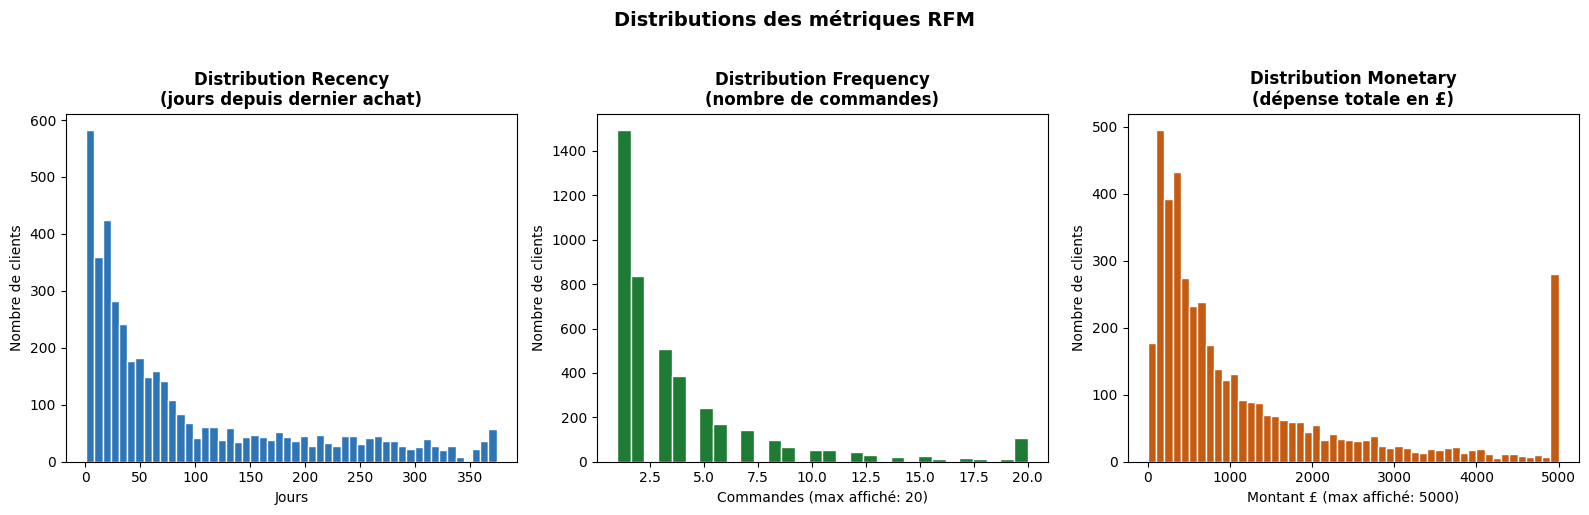

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Recency
axes[0].hist(rfm['Recency'], bins=50, color='#2E75B6', edgecolor='white')
axes[0].set_title('Distribution Recency\n(jours depuis dernier achat)', fontweight='bold')
axes[0].set_xlabel('Jours')
axes[0].set_ylabel('Nombre de clients')

# Frequency
axes[1].hist(rfm['Frequency'].clip(upper=20), bins=30, color='#1E7B34', edgecolor='white')
axes[1].set_title('Distribution Frequency\n(nombre de commandes)', fontweight='bold')
axes[1].set_xlabel('Commandes (max affiché: 20)')
axes[1].set_ylabel('Nombre de clients')

# Monetary
axes[2].hist(rfm['Monetary'].clip(upper=5000), bins=50, color='#C55A11', edgecolor='white')
axes[2].set_title('Distribution Monetary\n(dépense totale en £)', fontweight='bold')
axes[2].set_xlabel('Montant £ (max affiché: 5000)')
axes[2].set_ylabel('Nombre de clients')

plt.suptitle('Distributions des métriques RFM', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
#plt.savefig('', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# On divise chaque métrique en 5 groupes égaux (quintiles)
# Score 5 = meilleur client | Score 1 = moins bon client

# Recency : INVERSÉ — moins de jours = meilleur score
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1])

# Frequency : plus de commandes = meilleur score
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])

# Monetary : plus de dépenses = meilleur score
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])

# Score RFM global (somme des 3 scores)
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(int) +
    rfm['F_Score'].astype(int) +
    rfm['M_Score'].astype(int)
)

print("Scores RFM calculés (1 = faible, 5 = excellent)")
print()
print(rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary',
           'R_Score', 'F_Score', 'M_Score', 'RFM_Score']].head(10))

Scores RFM calculés (1 = faible, 5 = excellent)

   CustomerID  Recency  Frequency  Monetary R_Score F_Score M_Score  RFM_Score
0       12346      326          1  77183.60       1       1       5          7
1       12347        2          7   4310.00       5       5       5         15
2       12348       75          4   1797.24       2       4       4         10
3       12349       19          1   1757.55       4       1       4          9
4       12350      310          1    334.40       1       1       2          4
5       12352       36          8   2506.04       3       5       5         13
6       12353      204          1     89.00       1       1       1          3
7       12354      232          1   1079.40       1       1       4          6
8       12355      214          1    459.40       1       1       2          4
9       12356       23          3   2811.43       4       3       5         12


In [20]:
def assign_segment(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])
    score = row['RFM_Score']

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and score >= 10:
        return 'Clients Fidèles'
    elif r >= 4 and f <= 2:
        return 'Nouveaux Clients'
    elif r >= 3 and f >= 2 and m >= 3:
        return 'Clients Potentiels'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'Clients Endormis'
    elif r <= 2 and score <= 6:
        return 'Clients Perdus'
    else:
        return 'Clients Ordinaires'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

print("Segments attribués !")
print()
print(rfm['Segment'].value_counts())

Segments attribués !

Segment
Clients Perdus        1059
Champions              957
Clients Fidèles        763
Clients Ordinaires     657
Clients Endormis       453
Nouveaux Clients       319
Clients Potentiels     130
Name: count, dtype: int64


In [ ]:
def assign_segment(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])
    score = row['RFM_Score']

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'

    elif r >= 3 and f >= 3 and m >= 3:
        return 'Clients Fidèles'

    elif r >= 4 and f <= 2:
        return 'Nouveaux Clients'

    elif r >= 3 and f >= 2:
        return 'Clients Potentiels'

    elif r <= 2 and f >= 3:
        return 'Clients Endormis'

    elif r <= 2:
        return 'Clients Perdus'

    else:
        return 'Clients Ordinaires'

Visualiser la répartition des segments

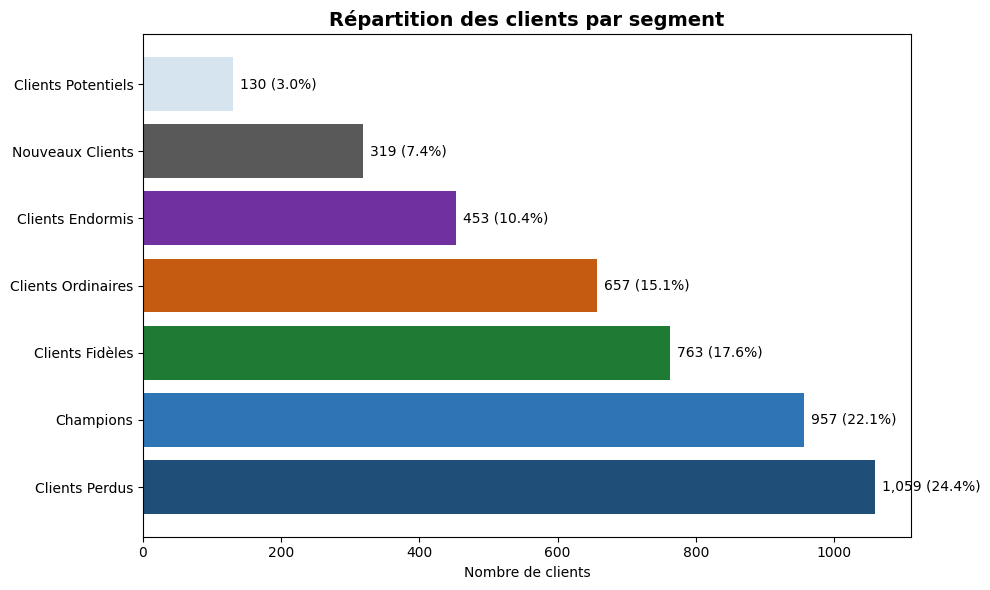

In [ ]:
segment_counts = rfm['Segment'].value_counts()

colors = ['#1F4E79', '#2E75B6', '#1E7B34', '#C55A11', '#7030A0', '#595959', '#D6E4F0']

plt.figure(figsize=(10, 6))
bars = plt.barh(segment_counts.index, segment_counts.values, color=colors[:len(segment_counts)])
plt.title('Répartition des clients par segment', fontsize=14, fontweight='bold')
plt.xlabel('Nombre de clients')

for bar, val in zip(bars, segment_counts.values):
    plt.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
             f'{val:,} ({val/len(rfm)*100:.1f}%)', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('', dpi=150, bbox_inches='tight')
plt.show()